# Week 7 — Multi-Agent Systems
## From Conway to LangGraph: Agent Systems for Physicists in the LLM Era
### Università di Bologna — Dipartimento di Fisica

---

**What this notebook covers:**

| Section | Topic |
|---------|-------|
| 0 | Setup & imports |
| 1 | PettingZoo primer — `simple_spread` anatomy |
| 2 | Random baseline — establish metrics |
| 3 | Independent Learners (IL) with parameter sharing |
| 4 | IL with separate policies — manual training loop |
| 5 | Diagnosing cooperative failure — non-stationarity metrics |
| 6 | CTDE conceptual sketch — what MADDPG changes |
| 7 | Bridge to GABM — from reward to persona |

**Prerequisites:** Week 6 (Gymnasium, PPO, SB3). No new RL theory is introduced here.

> **Physics thread:** A single spin in an external field → interacting spin system.
> Mean-field theory as first diagnostic. CTDE ≡ mean-field training + local execution.


## Section 0 — Setup

In [ ]:
# ── Install ────────────────────────────────────────────────────────────────
# Run once; takes ~60 s on Colab
!pip install "pettingzoo<=1.24.3" supersuit stable-baselines3 gymnasium torch --quiet


In [ ]:
import os
import warnings

os.environ["GYM_DISABLE_WARNINGS"] = "1"
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from pettingzoo.mpe import simple_spread_v3
import supersuit as ss
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecMonitor

print("All imports OK ✓")

---
## Section 1 — PettingZoo Primer: `simple_spread` anatomy

`simple_spread_v3` is a **cooperative** Multi-Particle Environment (MPE):
- $N$ agents (blue circles) must cover $N$ landmarks (black crosses)
- Reward = $-\sum_\ell \min_i d(i, \ell)$  — penalises uncovered landmarks
- Observation: relative positions of landmarks + other agents (18-dim for N=3)
- Action: 5 discrete moves — idle, up, down, left, right

We use the **Parallel API**: all agents submit actions simultaneously,
mirroring a synchronous physical system.


In [ ]:
# ── Inspect the environment ───────────────────────────────────────────────
env = simple_spread_v3.parallel_env(N=3, max_cycles=25, continuous_actions=False)
obs, infos = env.reset(seed=42)

print("Agents:", env.agents)
print()
for a in env.agents:
    print(f"  {a}  obs shape: {obs[a].shape}  "
          f"action_space: {env.action_space(a)}")
print()
print("Observation sample (agent_0):")
print(np.round(obs["agent_0"], 3))


In [ ]:
def run_episode(env, policy_fn, seed=0):
    """Run one episode; return per-step rewards and final collision count."""
    obs, _ = env.reset(seed=seed)
    total_rewards = defaultdict(float)
    step_rewards  = []

    while env.agents:
        actions = {a: policy_fn(a, obs[a]) for a in env.agents}
        obs, rew, term, trunc, _ = env.step(actions)
        step_rewards.append(sum(rew.values()) / len(rew))
        for a, r in rew.items():
            total_rewards[a] += r

    return total_rewards, step_rewards


def random_policy(agent, observation):
    return env.action_space(agent).sample()


env = simple_spread_v3.parallel_env(N=3, max_cycles=25, continuous_actions=False)
totals, steps = run_episode(env, random_policy, seed=0)

print("Episode total rewards (random policy):")
for a, r in totals.items():
    print(f"  {a}: {r:.3f}")
print(f"  Mean: {np.mean(list(totals.values())):.3f}")


In [ ]:
# ── Visualise one episode (reward per step) ──────────────────────────────
n_episodes = 20
ep_means = []
for ep in range(n_episodes):
    _, steps = run_episode(
        simple_spread_v3.parallel_env(N=3, max_cycles=25, continuous_actions=False),
        random_policy, seed=ep)
    ep_means.append(np.mean(steps))

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(n_episodes), ep_means, color="#4A9ECC", alpha=0.8)
ax.axhline(np.mean(ep_means), color="#E8B931", lw=2, ls="--",
           label=f"mean = {np.mean(ep_means):.3f}")
ax.set_xlabel("Episode")
ax.set_ylabel("Mean reward per step")
ax.set_title("Random policy baseline — simple_spread (N=3)")
ax.legend()
plt.tight_layout()
plt.show()

RANDOM_BASELINE = np.mean(ep_means)
print(f"Random baseline: {RANDOM_BASELINE:.4f}")


---
## Section 2 — Why Independent Learners break: a quick derivation

From each agent $i$'s perspective the **effective transition kernel** is:

$$P(s' \mid s, a_i) = \sum_{a_{-i}} P(s' \mid s, \mathbf{a})\, \pi_{-i}(a_{-i} \mid s)$$

This is **not stationary** as long as other agents' policies $\pi_{-i}$ are updating.
Three concrete consequences:

1. **Bellman invalidity** — $Q^*(s, a_i)$ implicitly depends on $\pi_{-i}$; solving the
   Bellman equation for one set of policies produces a wrong $Q$ when others change.

2. **Replay buffer poisoning** — old transitions $(s, a, r, s')$ were generated under
   older $\pi_{-i}$; replaying them introduces bias proportional to the policy shift.

3. **Credit assignment noise** — in a cooperative task the shared reward $r = \sum_i r_i$
   makes it impossible to attribute improvement to a specific agent's action.

> **Physics analogy.** Each agent tries to minimise its local free energy
> $\mathcal{F}_i = \mathbb{E}[-r_i] + \beta^{-1} H(\pi_i)$,
> but the landscape $\mathcal{F}_i$ itself deforms as other agents update.
> This is the MARL analogue of a non-equilibrium system where the Hamiltonian
> evolves faster than the dynamics can relax.


---
## Section 3 — IL with parameter sharing (SuperSuit + SB3 PPO)

The simplest IL variant: all agents share a **single** policy network.
`supersuit.pettingzoo_env_to_vec_env_v1` stacks all agents as parallel
"copies" of the same Gym environment — SB3 PPO treats them as a vectorised
single-agent problem.

This is equivalent to: every agent runs the same PPO update on its local
$(o_i, a_i, r_i)$ — no communication, no shared value function.

Advantage: dead-simple to implement with SB3.
Limitation: identical parameters for all agents; cannot specialise.


In [13]:
def make_shared_policy_env(n_agents=3, max_cycles=25, seed=0):
    """
    Wrap simple_spread for SB3 PPO with parameter sharing.
    supersuit.pettingzoo_env_to_vec_env stacks N agents as N envs.
    """
    env = simple_spread_v3.parallel_env(
        N=n_agents, max_cycles=max_cycles, continuous_actions=False)
    env = ss.pad_observations_v0(env)
    env = ss.pad_action_space_v0(env)
    env = ss.pettingzoo_env_to_vec_env_v1(env)   # N parallel envs
    env = ss.concat_vec_envs_v1(env, 1, base_class="stable_baselines3")
    env = VecMonitor(env)
    return env


# ── Train ────────────────────────────────────────────────────────────────
TOTAL_STEPS_SHARED = 200_000   # increase for better convergence

train_env = make_shared_policy_env()

# Patch compatibility: SuperSuit ConcatVecEnv lacks .seed()
if not hasattr(train_env, "seed"):
    train_env.seed = lambda seed=None: [seed] * train_env.num_envs

if not hasattr(train_env, "set_options"):
    train_env.set_options = lambda options=None: None

model_shared = PPO(
    "MlpPolicy",
    train_env,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=256,
    gamma=0.95,
    verbose=1,
)

print("Training shared-policy IL (parameter sharing)…")
model_shared.learn(total_timesteps=TOTAL_STEPS_SHARED)
print("Done ✓")


Using cpu device
Training shared-policy IL (parameter sharing)…
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 25       |
|    ep_rew_mean     | -25.3    |
| time/              |          |
|    fps             | 2473     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 3072     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 25           |
|    ep_rew_mean          | -26.7        |
| time/                   |              |
|    fps                  | 2172         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 6144         |
| train/                  |              |
|    approx_kl            | 0.0059033805 |
|    clip_fraction        | 0.0163       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.61    

In [14]:
# ── Evaluate shared policy ───────────────────────────────────────────────
def eval_sb3_model(model, n_episodes=30, n_agents=3, max_cycles=25):
    """
    Evaluate a trained SB3 model on raw PettingZoo env.
    Returns list of mean episode rewards.
    """
    ep_rewards = []
    eval_env = simple_spread_v3.parallel_env(
        N=n_agents, max_cycles=max_cycles, continuous_actions=False)

    for ep in range(n_episodes):
        obs, _ = eval_env.reset(seed=ep + 1000)
        ep_r = 0.0
        steps = 0
        while eval_env.agents:
            actions = {}
            for a in eval_env.agents:
                o = obs[a].reshape(1, -1)
                action, _ = model.predict(o, deterministic=True)
                actions[a] = int(action[0])
            obs, rew, term, trunc, _ = eval_env.step(actions)
            ep_r += sum(rew.values()) / max(len(rew), 1)
            steps += 1
        ep_rewards.append(ep_r / max(steps, 1))

    return ep_rewards


shared_rewards = eval_sb3_model(model_shared, n_episodes=30)
print(f"Shared-policy IL  mean reward: {np.mean(shared_rewards):.4f}  "
      f"±{np.std(shared_rewards):.4f}")
print(f"Random baseline              : {RANDOM_BASELINE:.4f}")
print(f"Improvement over random: "
      f"{(np.mean(shared_rewards) - RANDOM_BASELINE) / abs(RANDOM_BASELINE) * 100:.1f}%")


Shared-policy IL  mean reward: -0.8598  ±0.2777
Random baseline              : -1.0146
Improvement over random: 15.3%


---
## Section 4 — IL with separate policies: manual training loop

Here each agent maintains its own independent policy network (no sharing).
We implement a minimal **actor-only REINFORCE** loop to keep the code
readable and the non-stationarity signal visible.

This is not the most efficient algorithm — the goal is to expose the
training dynamics so we can measure the failure mode in Section 5.


In [15]:
# ── Minimal policy network ───────────────────────────────────────────────
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return torch.softmax(self.net(x), dim=-1)

    def act(self, obs_np):
        x = torch.tensor(obs_np, dtype=torch.float32).unsqueeze(0)
        probs = self(x)
        dist  = torch.distributions.Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action)


def discount_returns(rewards, gamma=0.95):
    G, returns = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns


In [16]:
# ── Training loop — separate policies ────────────────────────────────────
N_AGENTS   = 3
N_EPISODES = 600        # increase for better convergence (~2 min on Colab)
GAMMA      = 0.95
LR         = 3e-4
EVAL_EVERY = 50

env_sep = simple_spread_v3.parallel_env(N=N_AGENTS, max_cycles=25,
                                        continuous_actions=False)
obs_dim   = env_sep.observation_space("agent_0").shape[0]
n_actions = env_sep.action_space("agent_0").n

# One independent policy per agent
policies   = {f"agent_{i}": PolicyNet(obs_dim, n_actions) for i in range(N_AGENTS)}
optimisers = {a: optim.Adam(p.parameters(), lr=LR) for a, p in policies.items()}

# Tracking
train_rewards  = []          # mean episode reward across agents
reward_var_log = []          # variance across agents per episode (non-stationarity proxy)

for ep in range(N_EPISODES):
    obs, _ = env_sep.reset(seed=ep)
    ep_log_probs  = defaultdict(list)
    ep_rewards_ag = defaultdict(list)

    # ── Roll out one episode ────────────────────────────────────────────
    while env_sep.agents:
        actions = {}
        log_ps  = {}
        for a in env_sep.agents:
            action, lp = policies[a].act(obs[a])
            actions[a] = action
            log_ps[a]  = lp
        obs, rew, term, trunc, _ = env_sep.step(actions)
        for a in list(log_ps.keys()):
            ep_log_probs[a].append(log_ps[a])
            ep_rewards_ag[a].append(rew.get(a, 0.0))

    # ── REINFORCE update for each agent ────────────────────────────────
    for a in policies:
        if not ep_log_probs[a]:
            continue
        returns  = discount_returns(ep_rewards_ag[a], GAMMA)
        log_probs = torch.stack(ep_log_probs[a])
        loss = -(log_probs * returns).mean()
        optimisers[a].zero_grad()
        loss.backward()
        optimisers[a].step()

    # ── Logging ────────────────────────────────────────────────────────
    mean_ep = np.mean([sum(ep_rewards_ag[a]) for a in policies])
    var_ep  = np.var( [sum(ep_rewards_ag[a]) for a in policies])
    train_rewards.append(mean_ep)
    reward_var_log.append(var_ep)

    if (ep + 1) % EVAL_EVERY == 0:
        recent = np.mean(train_rewards[-EVAL_EVERY:])
        print(f"  ep {ep+1:4d}/{N_EPISODES}  "
              f"mean reward: {recent:6.3f}  "
              f"reward var: {np.mean(reward_var_log[-EVAL_EVERY:]):.4f}")

print("Training done ✓")


  ep   50/600  mean reward: -25.550  reward var: 0.1211
  ep  100/600  mean reward: -26.047  reward var: 0.1067
  ep  150/600  mean reward: -28.603  reward var: 0.1700
  ep  200/600  mean reward: -28.409  reward var: 0.1944
  ep  250/600  mean reward: -27.060  reward var: 0.1833
  ep  300/600  mean reward: -26.705  reward var: 0.2744
  ep  350/600  mean reward: -27.391  reward var: 0.1678
  ep  400/600  mean reward: -26.661  reward var: 0.1911
  ep  450/600  mean reward: -26.236  reward var: 0.1722
  ep  500/600  mean reward: -26.194  reward var: 0.1522
  ep  550/600  mean reward: -25.363  reward var: 0.1489
  ep  600/600  mean reward: -28.177  reward var: 0.1678
Training done ✓


---
## Section 5 — Diagnosing cooperative failure

We use three metrics to characterise the failure mode of IL:

1. **Mean episode reward** — overall performance vs random baseline.
2. **Between-agent reward variance** — measures how asymmetric learning is.
   High variance → one agent is "lazy" or stuck.  
   In a well-coordinated team this should be near zero.
3. **Learning curve smoothness** — non-stationarity manifests as oscillation;
   a well-converging single-agent problem has monotone improvement.

> **Physics analogy.** Reward variance across agents is the order parameter
> analogue: zero in the ferromagnetic (cooperative) phase, large in the
> disordered phase. The transition between the two is driven by the coupling
> strength (shared reward signal).


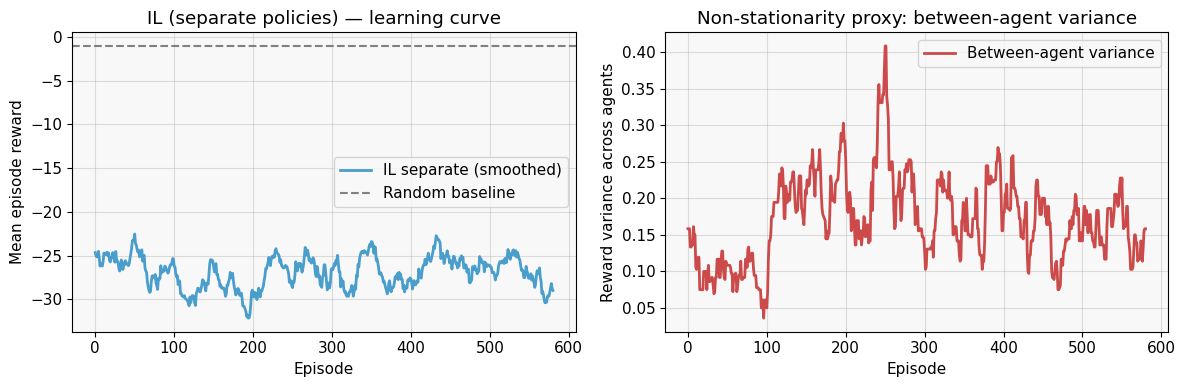

Final 50-ep mean reward : -28.1766
Final 50-ep reward var  : 0.1678
Random baseline         : -1.0146


In [17]:
# ── Smooth helper ───────────────────────────────────────────────────────
def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

# ── Plot 1: learning curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(smooth(train_rewards), color="#4A9ECC", lw=2, label="IL separate (smoothed)")
ax.axhline(RANDOM_BASELINE, color="gray", ls="--", lw=1.5, label="Random baseline")
ax.set_xlabel("Episode")
ax.set_ylabel("Mean episode reward")
ax.set_title("IL (separate policies) — learning curve")
ax.legend()

ax = axes[1]
ax.plot(smooth(reward_var_log), color="#CC4A4A", lw=2, label="Between-agent variance")
ax.set_xlabel("Episode")
ax.set_ylabel("Reward variance across agents")
ax.set_title("Non-stationarity proxy: between-agent variance")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Final 50-ep mean reward : {np.mean(train_rewards[-50:]):.4f}")
print(f"Final 50-ep reward var  : {np.mean(reward_var_log[-50:]):.4f}")
print(f"Random baseline         : {RANDOM_BASELINE:.4f}")


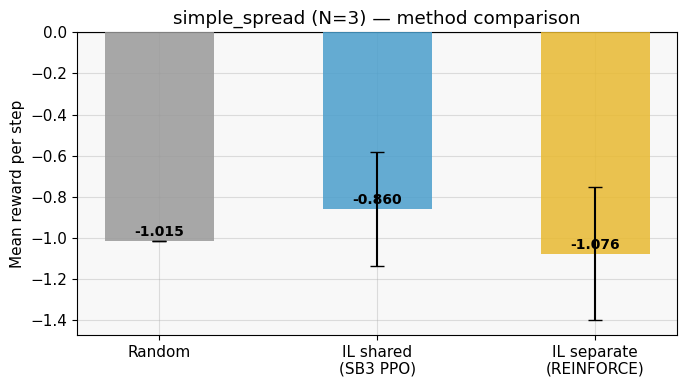

In [19]:
# ── Plot 2: compare random vs IL shared vs IL separate ───────────────────
def eval_separate_policies(policies, n_episodes=30):
    ev = simple_spread_v3.parallel_env(N=3, max_cycles=25, continuous_actions=False)
    ep_rewards = []
    for ep in range(n_episodes):
        obs, _ = ev.reset(seed=ep + 2000)
        ep_r, steps = 0.0, 0
        while ev.agents:
            actions = {}
            for a in ev.agents:
                if a in policies:
                    action, _ = policies[a].act(obs[a])
                    actions[a] = action
                else:
                    actions[a] = ev.action_space(a).sample()
            obs, rew, _, _, _ = ev.step(actions)
            ep_r += sum(rew.values()) / max(len(rew), 1)
            steps += 1
        ep_rewards.append(ep_r / max(steps, 1))
    return ep_rewards


sep_rewards = eval_separate_policies(policies, n_episodes=30)

labels = [
    "Random",
    "IL shared\n(SB3 PPO)",
    "IL separate\n(REINFORCE)"
]
means   = [RANDOM_BASELINE,
           np.mean(shared_rewards),
           np.mean(sep_rewards)]
stds    = [np.std([]),
           np.std(shared_rewards),
           np.std(sep_rewards)]
colors  = ["#999999", "#4A9ECC", "#E8B931"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, means, color=colors, alpha=0.85, width=0.5, zorder=3)
ax.errorbar(labels, means, yerr=[0, stds[1], stds[2]],
            fmt='none', color='black', capsize=5, lw=1.5, zorder=4)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel("Mean reward per step")
ax.set_title("simple_spread (N=3) — method comparison")
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.01,
            f"{m:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


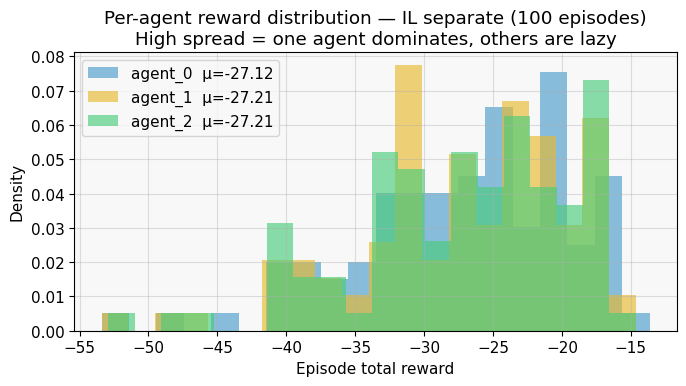


Between-agent reward std (higher = more asymmetric / broken cooperation):
  {'agent_0': np.float64(-27.115331669522647), 'agent_1': np.float64(-27.21033166952265), 'agent_2': np.float64(-27.21033166952265)}
  std across agents: 0.0448


In [21]:
# ── Plot 3: per-agent reward distribution (last 100 episodes) ────────────
per_agent = defaultdict(list)
env_diag = simple_spread_v3.parallel_env(N=3, max_cycles=25, continuous_actions=False)

for ep in range(100):
    obs, _ = env_diag.reset(seed=ep + 5000)
    totals = defaultdict(float)
    while env_diag.agents:
        actions = {}
        for a in env_diag.agents:
            if a in policies:
                action, _ = policies[a].act(obs[a])
                actions[a] = action
            else:
                actions[a] = env_diag.action_space(a).sample()
        obs, rew, _, _, _ = env_diag.step(actions)
        for a, r in rew.items():
            totals[a] += r
    for a, r in totals.items():
        per_agent[a].append(r)

fig, ax = plt.subplots(figsize=(7, 4))
agent_colors = ["#4A9ECC", "#E8B931", "#4ACC7A"]
for i, (a, rs) in enumerate(per_agent.items()):
    ax.hist(rs, bins=20, alpha=0.65, color=agent_colors[i],
            label=f"{a}  μ={np.mean(rs):.2f}", density=True)
ax.set_xlabel("Episode total reward")
ax.set_ylabel("Density")
ax.set_title(
    "Per-agent reward distribution — IL separate (100 episodes)\n"
    "High spread = one agent dominates, others are lazy"
)
ax.legend()
plt.tight_layout()
plt.show()

print("\nBetween-agent reward std (higher = more asymmetric / broken cooperation):")
agent_means = {a: np.mean(rs) for a, rs in per_agent.items()}
print(f"  {agent_means}")
print(f"  std across agents: {np.std(list(agent_means.values())):.4f}")


---
## Section 6 — CTDE: what MADDPG changes

**Centralised Training, Decentralised Execution (CTDE)** is the architectural
fix for the non-stationarity problem.

### What changes in the critic

In IL, agent $i$ has a value function $V_{\phi_i}(o_i)$ — it can only see
its own observation.

In MADDPG the critic is **centralised**:

$$Q_{\phi_i}(\underbrace{o_1,\ldots,o_N}_{\text{global obs}},
               \underbrace{a_1,\ldots,a_N}_{\text{joint action}})$$

This critic is only used **during training** to compute a stable advantage
estimate. At execution time each agent still uses only $o_i$.

### Why this fixes non-stationarity

Because the centralised critic conditions on **all** agents' current actions,
it sees $\pi_{-i}$ explicitly — the environment looks stationary from the
critic's perspective.

### Physics analogy

| | Single-agent | IL | CTDE |
|---|---|---|---|
| Critic | $V(o_i)$ | $V_{\phi_i}(o_i)$ | $Q_{\phi_i}(\mathbf{o}, \mathbf{a})$ |
| Effective field | external $h$ | noisy $h_i^\text{eff}$ (shifting) | correct $h_i^\text{eff}$ (stable) |
| Actor | $\pi(o_i)$ | $\pi_{\theta_i}(o_i)$ | $\pi_{\theta_i}(o_i)$ — same! |

The actor is identical in IL and CTDE.
Only the training signal changes.


In [22]:
# ── MADDPG critic architecture (skeleton) ────────────────────────────────
class MADDPGCritic(nn.Module):
    """
    Centralised critic for agent i.
    Input: concatenation of ALL agents' observations + ALL agents' actions.
    Output: scalar Q-value for agent i.

    At execution time this network is discarded — only the actor runs.
    """
    def __init__(self, n_agents, obs_dim, n_actions, hidden=128):
        super().__init__()
        # Joint input dimension: all obs + all one-hot actions
        joint_dim = n_agents * obs_dim + n_agents * n_actions
        self.net = nn.Sequential(
            nn.Linear(joint_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, all_obs, all_actions_onehot):
        # all_obs:          (batch, n_agents * obs_dim)
        # all_actions_onehot: (batch, n_agents * n_actions)
        x = torch.cat([all_obs, all_actions_onehot], dim=-1)
        return self.net(x)


class MADDPGActor(nn.Module):
    """
    Decentralised actor for agent i.
    Input:  o_i  (local observation only)
    Output: action probabilities
    This is IDENTICAL to the IL actor — the only change is how it is trained.
    """
    def __init__(self, obs_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
            nn.Linear(hidden, n_actions), nn.Softmax(dim=-1),
        )

    def forward(self, obs):
        return self.net(obs)


# Instantiate for simple_spread N=3
n_agents, obs_d, n_act = 3, obs_dim, n_actions
critics = [MADDPGCritic(n_agents, obs_d, n_act) for _ in range(n_agents)]
actors  = [MADDPGActor(obs_d, n_act) for _ in range(n_agents)]

print("MADDPG critic parameter count:",
      sum(p.numel() for p in critics[0].parameters()))
print("MADDPG actor  parameter count:",
      sum(p.numel() for p in actors[0].parameters()))
print()
print("Key insight: the ACTOR is identical to an IL actor.")
print("Only the CRITIC sees the joint (obs, actions) — and only during training.")


MADDPG critic parameter count: 25601
MADDPG actor  parameter count: 5701

Key insight: the ACTOR is identical to an IL actor.
Only the CRITIC sees the joint (obs, actions) — and only during training.


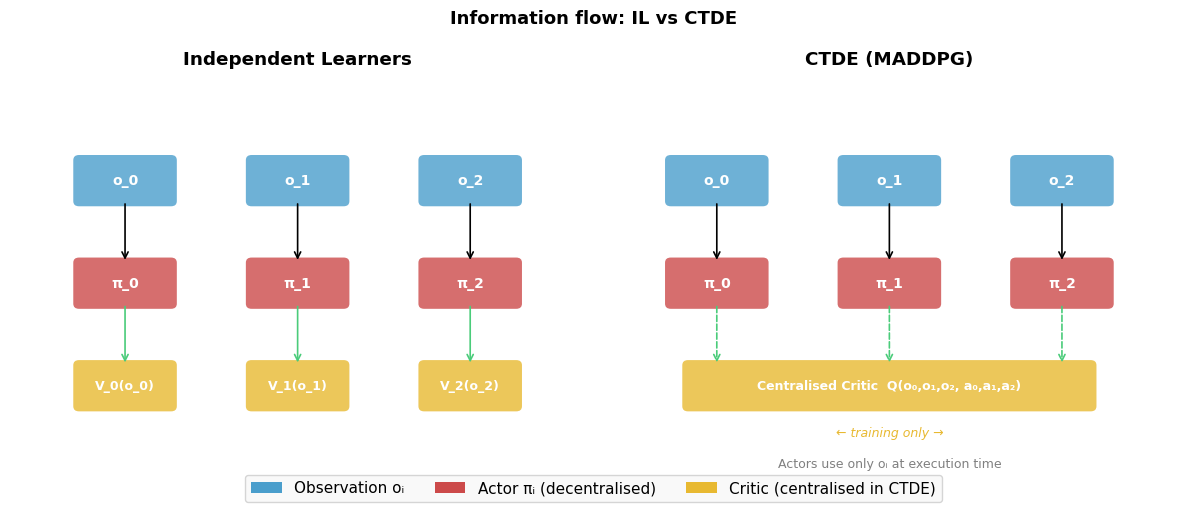

In [23]:
# ── Diagram: IL vs CTDE information flow ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Information flow: IL vs CTDE", fontsize=13, fontweight='bold')

colors = {"obs": "#4A9ECC", "action": "#4ACC7A",
          "critic": "#E8B931", "actor": "#CC4A4A"}

for ax, (title, use_ctde) in zip(axes, [("Independent Learners", False),
                                         ("CTDE (MADDPG)", True)]):
    ax.set_xlim(0, 10); ax.set_ylim(0, 8)
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

    # Three agent columns
    for i, (xc, ag) in enumerate([(2, "agent 0"), (5, "agent 1"), (8, "agent 2")]):
        # Observation box
        obs_box = mpatches.FancyBboxPatch((xc-0.8, 5.5), 1.6, 0.8,
            boxstyle="round,pad=0.1", fc=colors["obs"], ec="none", alpha=0.8)
        ax.add_patch(obs_box)
        ax.text(xc, 5.9, f"o_{i}", ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

        # Actor box
        act_box = mpatches.FancyBboxPatch((xc-0.8, 3.5), 1.6, 0.8,
            boxstyle="round,pad=0.1", fc=colors["actor"], ec="none", alpha=0.8)
        ax.add_patch(act_box)
        ax.text(xc, 3.9, f"π_{i}", ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

        # Arrow obs → actor
        ax.annotate("", xy=(xc, 4.3), xytext=(xc, 5.5),
                    arrowprops=dict(arrowstyle="->", color="black", lw=1.2))

        # Critic box
        if use_ctde:
            if i == 1:   # single central label
                crit_box = mpatches.FancyBboxPatch((1.5, 1.5), 7.0, 0.8,
                    boxstyle="round,pad=0.1", fc=colors["critic"], ec="none", alpha=0.8)
                ax.add_patch(crit_box)
                ax.text(5, 1.9, "Centralised Critic  Q(o₀,o₁,o₂, a₀,a₁,a₂)",
                        ha='center', va='center', fontsize=9, fontweight='bold',
                        color='white')
            # Arrows to central critic (dashed = training only)
            ax.annotate("", xy=(xc, 2.3), xytext=(xc, 3.5),
                        arrowprops=dict(arrowstyle="->", color=colors["action"],
                                       lw=1.2, linestyle="dashed"))
        else:
            crit_box = mpatches.FancyBboxPatch((xc-0.8, 1.5), 1.6, 0.8,
                boxstyle="round,pad=0.1", fc=colors["critic"], ec="none", alpha=0.8)
            ax.add_patch(crit_box)
            ax.text(xc, 1.9, f"V_{i}(o_{i})", ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
            ax.annotate("", xy=(xc, 2.3), xytext=(xc, 3.5),
                        arrowprops=dict(arrowstyle="->", color=colors["action"],
                                       lw=1.2))

    if use_ctde:
        ax.text(5, 0.9, "← training only →", ha='center', fontsize=9,
                color=colors["critic"], fontstyle='italic')
        ax.text(5, 0.3, "Actors use only oᵢ at execution time",
                ha='center', fontsize=9, color="gray")

legend_elems = [
    mpatches.Patch(fc=colors["obs"],    label="Observation oᵢ"),
    mpatches.Patch(fc=colors["actor"],  label="Actor πᵢ (decentralised)"),
    mpatches.Patch(fc=colors["critic"], label="Critic (centralised in CTDE)"),
]
fig.legend(handles=legend_elems, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


---
## Section 7 — From reward-driven to goal-driven: the GABM bridge

The MARL pipeline we have built — observation, policy, action, reward —
is the right abstraction regardless of how the policy is implemented.

The key insight is that we can **swap the policy implementation** while
keeping the multi-agent interaction structure intact:

```
Gradient descent on R(s,a)   →   Policy from pre-trained language model
Reward shaping               →   Natural language goal description
Anonymous agent              →   Demographic profile (age, income, health...)
No memory                    →   Memory stream + retrieval
```

This is what **Generative Agent-Based Models (GABM)** do:
each "particle" in the system is an LLM conditioned on a persona,
with an explicit memory, a planning module, and a reflection mechanism.

The interaction structure is still a MAS — the environment, the observation,
the action space. Only the policy source changes.

### A toy LLM agent sketch


In [24]:
# ── Toy illustration: LLM agent interface ────────────────────────────────
# (No actual LLM call — just showing the architecture pattern)

class LLMAgentSketch:
    """
    Minimal sketch of a GABM agent structure.
    In a real system, self.llm would call an API (GPT-4, Claude, etc.)
    """
    def __init__(self, agent_id, persona: dict):
        self.agent_id   = agent_id
        self.persona    = persona       # demographic profile
        self.memory     = []            # memory stream

    def observe(self, percepts: dict):
        """Add new percepts to memory stream."""
        entry = {"time": len(self.memory), "percepts": percepts}
        self.memory.append(entry)

    def _retrieve(self, k=5) -> str:
        """Return the k most recent memory entries as context string."""
        recent = self.memory[-k:] if len(self.memory) >= k else self.memory
        return "\n".join(
            f"[t={e['time']}] " + ", ".join(f"{k}={v}"
            for k, v in e['percepts'].items())
            for e in recent
        )

    def act(self, goal: str) -> str:
        """
        In a real system: call LLM with persona + memory + goal → action.
        Here we just print the prompt that would be sent.
        """
        context = self._retrieve()
        prompt = (
            f"You are {self.persona['name']}, "
            f"age {self.persona['age']}, "
            f"income level: {self.persona['income']}.\n"
            f"Recent observations:\n{context}\n"
            f"Your goal: {goal}\n"
            f"What do you do next? (one short action)"
        )
        print("─" * 60)
        print(f"AGENT {self.agent_id} PROMPT:")
        print(prompt)
        print("─" * 60)
        # In a real system: return llm(prompt)
        return "[LLM response would go here]"


# Example: two synthetic agents with different demographic profiles
agent_alice = LLMAgentSketch(
    agent_id=0,
    persona={"name": "Alice", "age": 32, "income": "middle",
             "health": "healthy", "location": "Bologna"}
)
agent_bob = LLMAgentSketch(
    agent_id=1,
    persona={"name": "Bob", "age": 68, "income": "low",
             "health": "diabetic", "location": "rural Emilia"}
)

# Simulate observations (e.g. from a COVID-19 model)
agent_alice.observe({"new_cases_nearby": 15, "lockdown_level": 1,
                     "vaccination_status": "vaccinated"})
agent_bob.observe({"new_cases_nearby": 3, "lockdown_level": 0,
                   "vaccination_status": "unvaccinated"})

# Query for action
_ = agent_alice.act(goal="Decide whether to go to work today.")


────────────────────────────────────────────────────────────
AGENT 0 PROMPT:
You are Alice, age 32, income level: middle.
Recent observations:
[t=0] new_cases_nearby=15, lockdown_level=1, vaccination_status=vaccinated
Your goal: Decide whether to go to work today.
What do you do next? (one short action)
────────────────────────────────────────────────────────────


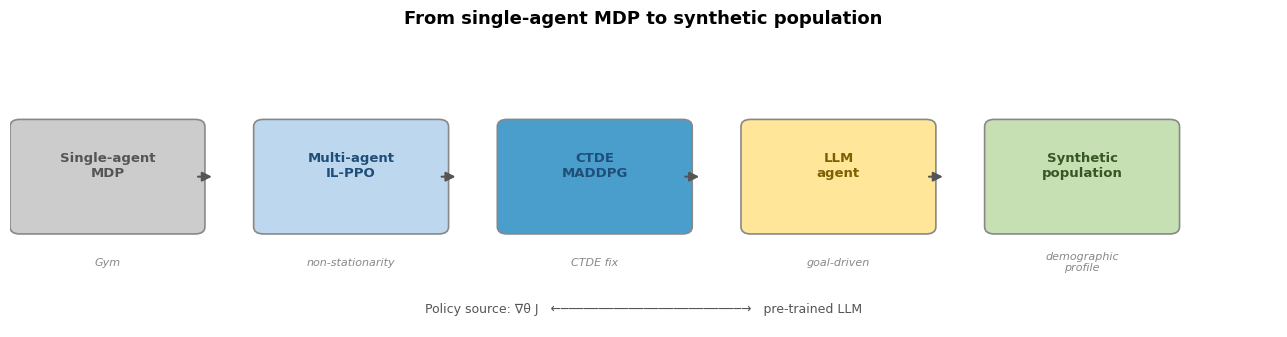

In [25]:
# ── Full pipeline summary diagram ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 4); ax.axis('off')
ax.set_title("From single-agent MDP to synthetic population",
             fontsize=13, fontweight='bold', pad=12)

stages = [
    ("Single-agent\nMDP",        "Gym",             "#CCCCCC", "#555555"),
    ("Multi-agent\nIL-PPO",      "non-stationarity","#BDD7EE", "#1F4E79"),
    ("CTDE\nMADDPG",             "CTDE fix",        "#4A9ECC", "#1F4E79"),
    ("LLM\nagent",               "goal-driven",     "#FFE699", "#7F6000"),
    ("Synthetic\npopulation",    "demographic\nprofile","#C6E0B4","#375623"),
]

xpos = [1.0, 3.5, 6.0, 8.5, 11.0]
for (label, sublabel, fc, tc), x in zip(stages, xpos):
    box = mpatches.FancyBboxPatch((x-0.9, 1.4), 1.8, 1.4,
        boxstyle="round,pad=0.1", fc=fc, ec="#888888", lw=1.2)
    ax.add_patch(box)
    ax.text(x, 2.25, label, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color=tc)
    ax.text(x, 0.9, sublabel, ha='center', va='center',
            fontsize=8, color="#888888", fontstyle='italic')

for x in [1.9, 4.4, 6.9, 9.4]:
    ax.annotate("", xy=(x+0.2, 2.1), xytext=(x, 2.1),
                arrowprops=dict(arrowstyle="-|>", color="#555555",
                               lw=1.5, mutation_scale=14))

ax.text(6.5, 0.2,
        "Policy source: ∇θ J   ←────────────────────────→   pre-trained LLM",
        ha='center', fontsize=9, color="#555555")

plt.tight_layout()
plt.show()


---
## What's next

This notebook has covered the **Week 7** content:

1. **PettingZoo** — the standard MARL environment library
2. **Independent Learners** — the simplest baseline, and why it breaks
3. **Non-stationarity diagnostics** — reward variance, learning curves
4. **CTDE / MADDPG** — the architectural fix: centralised critic at training time
5. **GABM bridge** — from gradient-trained policy to LLM-conditioned persona

**Next sessions** will build on this scaffolding with:
- Generative Agent-Based Models in practice
- Synthetic populations with demographic profiles
- AgentTorch at scale: $10^6$ agents, GPU-accelerated
- Calibration against real census and mobility data

> *The interacting spin system has become intelligent.*
